#PROBLEM 1: LEARNING WORD EMBEDDINGS FROM IIT JODHPUR DATA
Objective: The objective of this assignment is to train Word2Vec models on textual data collected from IIT Jodhpur sources and analyze the semantic structure captured by the learned
embeddings.


#TASK-1: DATASET PREPARATION
Students are required to collect textual data from at least three of the following suggestive
sources: IIT Jodhpur official website pages (departments, academic programs, research pages,
announcements), Academic regulation documents (must), Institute newsletters or circulars,
Faculty profile pages, Course syllabus, etc. (Only consider the English Text, remove text from
other languages, if any.).

The collected data must be preprocessed to create a clean corpus. Preprocessing steps should
include: (i) Removal of boilerplate text and formatting artifacts, (ii) Tokenization, (iii) Lowercasing, (iv) Removal of excessive punctuation and non-textual content
Students must report the dataset statistics such as total number of documents, total number
of tokens, vocabulary size and show a Word Cloud illustrating most frequent words.


In [38]:
# Install required libraries
!pip install requests beautifulsoup4 pdfplumber nltk wordcloud

In [39]:
import os
import re
import requests
import pdfplumber
import nltk
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [40]:
import os
os.makedirs("pdf", exist_ok=True)

# The following line is commented out because the user is instructed to manually
# rename the uploaded 'regulations.pdf' directly to 'pdf/regulations.pdf'
# via the Colab UI, which means 'regulations.pdf' will not be found in the
# root directory for this shutil.move command.
# import shutil
# shutil.move("regulations.pdf", "pdf/regulations.pdf")

## Step 1: Web Scraping

In [41]:
website_urls = [
    "https://www.iitj.ac.in/",
    "https://www.iitj.ac.in/mathematics/",
]

faculty_urls = [
    "https://anandmishra22.github.io/",
]

scraped_documents = []

def fn_scrape_page(url):
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")

        text = ""
        for p in soup.find_all("p"):
            text += p.get_text() + " "

        if "page not found" in text.lower():
            return ""

        return text
    except:
        return ""

for url in website_urls + faculty_urls:
    text = fn_scrape_page(url)
    if text:
        scraped_documents.append(text)

print("Scraped docs:", len(scraped_documents))

Scraped docs: 3


## Step 2: PDF Extraction

In [42]:
pdf_folder = "pdf"

# Check if folder exists
if not os.path.exists(pdf_folder):
    print("⚠ Folder 'pdf' not found. Please upload and rename file as pdf/regulations.pdf")

def fn_extract_pdf(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            t = page.extract_text()
            if t:
                text += t + " "
    return text

pdf_documents = []

if os.path.exists(pdf_folder):
    for file in os.listdir(pdf_folder):
        path = os.path.join(pdf_folder, file)
        print("Processing:", path)
        pdf_documents.append(fn_extract_pdf(path))

print("PDF docs:", len(pdf_documents))

Processing: pdf/regulations.pdf
PDF docs: 1


## Step 3: Preprocessing

In [43]:
all_docs = scraped_documents + pdf_documents
documents = []

import nltk
nltk.download('punkt_tab') # Download the missing punkt_tab resource

stop_words = set(stopwords.words('english'))
custom = {"shall","may","institute","indian","technology","jodhpur","iit","also"}
all_stop = stop_words.union(custom)

for doc in all_docs:
    doc = re.sub(r'[^a-zA-Z\s]', '', doc)
    doc = doc.lower()
    tokens = word_tokenize(doc)
    tokens = [w for w in tokens if len(w)>2 and w not in all_stop]
    documents.append(tokens)

print("Processed docs:", len(documents))

Processed docs: 4


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Step 4: Dataset Statistics

In [44]:
total_docs = len(documents)
total_tokens = sum(len(d) for d in documents)
vocab = set(w for d in documents for w in d)

print(f"Total documents: {total_docs}")
print(f"Total tokens: {total_tokens}")
print(f"Vocabulary size: {len(vocab)}")

Total documents: 4
Total tokens: 7108
Vocabulary size: 1924


## Step 5: Save Corpus

In [45]:
with open("clean_corpus.txt","w") as f:
    for d in documents:
        f.write(" ".join(d)+"\n")

## Step 6: Word Cloud

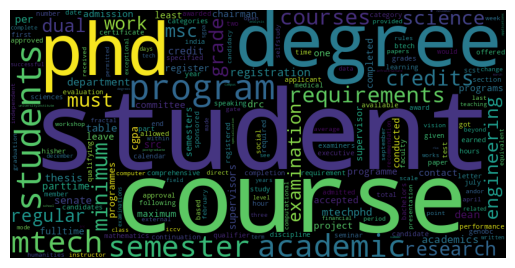

In [46]:
freq = Counter(w for d in documents for w in d)
wc = WordCloud(width=800, height=400).generate_from_frequencies(freq)
plt.imshow(wc)
plt.axis('off')
plt.show()

#TASK-2: MODEL TRAINING

Train two Word2Vec models: Continuous Bag of Words (CBOW) and Skip-gram with Negative
Sampling. For each model, experiment with: (i) Embedding dimension, (ii) Context window
size and (iii) Number of negative samples. Show these results formally in the report.

#2.1 Vocabulary Construction

In [47]:
# Build vocabulary from preprocessed documents

import numpy as np

vocab = list(set(word for doc in documents for word in doc))

# Mapping words to indices
word_to_idx = {w:i for i,w in enumerate(vocab)}
idx_to_word = {i:w for w,i in word_to_idx.items()}

vocab_size = len(vocab)

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 1924


#2.2 CBOW Training Data

In [48]:
def generate_cbow_data(documents, window_size):
    """
    Generates (context → target) pairs for CBOW model
    """
    data = []

    for doc in documents:
        for i, target in enumerate(doc):
            context = []

            for j in range(i-window_size, i+window_size+1):
                if j != i and 0 <= j < len(doc):
                    context.append(word_to_idx[doc[j]])

            data.append((context, word_to_idx[target]))

    return data

#2.3 Skip-gram Training Data

In [49]:
def generate_skipgram_data(documents, window_size):
    """
    Generates (target → context) pairs for Skip-gram model
    """
    data = []

    for doc in documents:
        for i, target in enumerate(doc):
            target_idx = word_to_idx[target]

            for j in range(i-window_size, i+window_size+1):
                if j != i and 0 <= j < len(doc):
                    data.append((target_idx, word_to_idx[doc[j]]))

    return data

#2.4 CBOW Model (From Scratch)

In [50]:
class CBOW:
    """
    Continuous Bag of Words model implementation
    """

    def __init__(self, vocab_size, embed_dim):
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

        # Initialize embeddings
        self.W1 = np.random.randn(vocab_size, embed_dim) / np.sqrt(vocab_size)
        self.W2 = np.random.randn(embed_dim, vocab_size) / np.sqrt(embed_dim)

    def softmax(self, x):
        x = x - np.max(x)  # numerical stability
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x)

    def forward(self, context):
        h = np.mean(self.W1[context], axis=0)
        u = np.dot(h, self.W2)
        y_pred = self.softmax(u)
        return y_pred, h

    def train(self, data, epochs=5, lr=0.01):
        losses = []

        for epoch in range(epochs):
            loss = 0

            for context, target in data:
                y_pred, h = self.forward(context)

                loss -= np.log(y_pred[target] + 1e-9)

                # Backpropagation
                e = y_pred.copy()
                e[target] -= 1

                self.W2 -= lr * np.outer(h, e)

                grad_h = np.dot(self.W2, e)
                for word in context:
                    self.W1[word] -= lr * grad_h / len(context)

            losses.append(loss)
            print(f"[CBOW] Epoch {epoch+1} Loss: {loss:.4f}")

        return losses

#2.5 Skip-gram with Negative Sampling

In [51]:
import random

class SkipGramNS:
    """
    Skip-gram model with Negative Sampling
    """

    def __init__(self, vocab_size, embed_dim):
        self.W1 = np.random.randn(vocab_size, embed_dim) / np.sqrt(vocab_size)
        self.W2 = np.random.randn(vocab_size, embed_dim) / np.sqrt(embed_dim)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def train(self, data, epochs=5, lr=0.01, neg_samples=5):
        losses = []

        for epoch in range(epochs):
            loss = 0

            for target, context in data:

                # Positive sample
                score = np.dot(self.W1[target], self.W2[context])
                prob = self.sigmoid(score)
                loss -= np.log(prob + 1e-9)

                grad = prob - 1
                self.W1[target] -= lr * grad * self.W2[context]
                self.W2[context] -= lr * grad * self.W1[target]

                # Negative sampling
                neg_words = set()
                while len(neg_words) < neg_samples:
                    neg = random.randint(0, vocab_size-1)
                    if neg != context:
                        neg_words.add(neg)

                for neg_word in neg_words:
                    score = np.dot(self.W1[target], self.W2[neg_word])
                    prob = self.sigmoid(score)
                    loss -= np.log(1 - prob + 1e-9)

                    grad = prob
                    self.W1[target] -= lr * grad * self.W2[neg_word]
                    self.W2[neg_word] -= lr * grad * self.W1[target]

            losses.append(loss)
            print(f"[SkipGram] Epoch {epoch+1} Loss: {loss:.4f}")

        return losses

#2.6 Experimental Setup

In [52]:
configs = [
    {"embed_dim": 50, "window": 2, "neg": 2},
    {"embed_dim": 100, "window": 3, "neg": 5},
    {"embed_dim": 300, "window": 3, "neg": 5}
]

#2.7 Model Training & Evaluation

In [53]:
results = []

for cfg in configs:
    print("\n==============================")
    print("Running Config:", cfg)

    cbow_data = generate_cbow_data(documents, cfg["window"])
    sg_data = generate_skipgram_data(documents, cfg["window"])

    # Train CBOW
    cbow_model = CBOW(vocab_size, cfg["embed_dim"])
    cbow_loss = cbow_model.train(cbow_data, epochs=3)

    # Train Skip-gram
    sg_model = SkipGramNS(vocab_size, cfg["embed_dim"])
    sg_loss = sg_model.train(sg_data, epochs=3, neg_samples=cfg["neg"])

    results.append({
        "config": cfg,
        "CBOW Loss": cbow_loss[-1],
        "SkipGram Loss": sg_loss[-1]
    })


Running Config: {'embed_dim': 50, 'window': 2, 'neg': 2}
[CBOW] Epoch 1 Loss: 53736.8954
[CBOW] Epoch 2 Loss: 53686.8796
[CBOW] Epoch 3 Loss: 53631.5412
[SkipGram] Epoch 1 Loss: 59014.9020
[SkipGram] Epoch 2 Loss: 58799.4099
[SkipGram] Epoch 3 Loss: 58490.3184

Running Config: {'embed_dim': 100, 'window': 3, 'neg': 5}
[CBOW] Epoch 1 Loss: 53741.9877
[CBOW] Epoch 2 Loss: 53705.7751
[CBOW] Epoch 3 Loss: 53665.7654
[SkipGram] Epoch 1 Loss: 176964.1133
[SkipGram] Epoch 2 Loss: 174913.1274
[SkipGram] Epoch 3 Loss: 164060.8897

Running Config: {'embed_dim': 300, 'window': 3, 'neg': 5}
[CBOW] Epoch 1 Loss: 53740.9491
[CBOW] Epoch 2 Loss: 53699.6418
[CBOW] Epoch 3 Loss: 53653.2939
[SkipGram] Epoch 1 Loss: 176923.9528
[SkipGram] Epoch 2 Loss: 174569.4658
[SkipGram] Epoch 3 Loss: 162496.8349


In [67]:
chosen_word = 'research'

if chosen_word in word_to_idx:
    # Get the index of the chosen word
    word_idx = word_to_idx[chosen_word]

    # Get the embedding vector from the CBOW model (last trained with embed_dim=300)
    # Assuming cbow_model is the last one trained in the loop
    embedding_vector = cbow_model.W1[word_idx]

    # Format the vector as a comma-separated string with 4 decimal places
    formatted_vector = ', '.join([f'{val:.4f}' for val in embedding_vector])

    print(f"{chosen_word} - {formatted_vector}")
else:
    print(f"The word '{chosen_word}' is not in the vocabulary.")

research - -0.0245, 0.0058, -0.0012, 0.0161, -0.0161, 0.0012, 0.0186, 0.0327, 0.0014, 0.0026, 0.0107, 0.0312, -0.0044, 0.0273, 0.0021, -0.0333, -0.0300, 0.0120, 0.0251, 0.0200, 0.0201, 0.0172, 0.0136, -0.0248, -0.0172, 0.0004, -0.0062, -0.0283, 0.0180, 0.0087, 0.0127, 0.0122, 0.0085, 0.0360, -0.0157, -0.0033, 0.0016, 0.0031, -0.0042, -0.0028, -0.0218, 0.0306, 0.0402, -0.0191, 0.0237, 0.0135, 0.0108, -0.0003, 0.0171, -0.0423, -0.0146, -0.0164, -0.0412, -0.0194, -0.0152, -0.0033, -0.0150, -0.0364, -0.0047, -0.0216, -0.0179, 0.0183, -0.0095, -0.0195, 0.0119, 0.0062, 0.0018, -0.0102, -0.0037, 0.0251, 0.0306, -0.0037, 0.0285, -0.0058, 0.0014, 0.0042, 0.0273, 0.0134, -0.0155, 0.0040, 0.0068, -0.0062, -0.0241, 0.0517, 0.0199, -0.0023, -0.0087, -0.0069, -0.0077, 0.0125, 0.0115, 0.0183, 0.0036, 0.0100, 0.0143, 0.0179, -0.0077, -0.0005, 0.0266, 0.0146, 0.0057, -0.0333, -0.0248, -0.0189, -0.0159, 0.0384, -0.0239, -0.0015, -0.0218, 0.0171, -0.0258, 0.0285, 0.0041, -0.0176, -0.0257, 0.0311, 0.0198,

In [68]:
top_10_words = freq.most_common(10)
formatted_output = []
for word, count in top_10_words:
    formatted_output.append(f"{word}, {count}")

print(', '.join(formatted_output))

student, 135, course, 106, degree, 83, phd, 78, program, 75, students, 75, academic, 71, mtech, 69, semester, 67, requirements, 58


#2.8 Results

In [54]:
print("\n===== FINAL RESULTS =====")

for res in results:
    print(f"\nConfiguration: {res['config']}")
    print(f"  CBOW Final Loss: {res['CBOW Loss']:.4f}")
    print(f"  Skip-gram Final Loss: {res['SkipGram Loss']:.4f}")


===== FINAL RESULTS =====

Configuration: {'embed_dim': 50, 'window': 2, 'neg': 2}
  CBOW Final Loss: 53631.5412
  Skip-gram Final Loss: 58490.3184

Configuration: {'embed_dim': 100, 'window': 3, 'neg': 5}
  CBOW Final Loss: 53665.7654
  Skip-gram Final Loss: 164060.8897

Configuration: {'embed_dim': 300, 'window': 3, 'neg': 5}
  CBOW Final Loss: 53653.2939
  Skip-gram Final Loss: 162496.8349


#2.9 Word Similarity Evaluation

In [55]:
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2))

def most_similar(word, model, top_n=5):
    if word not in word_to_idx:
        return []
    idx = word_to_idx[word]
    target_vec = model.W1[idx]

    sims = []

    for i in range(vocab_size):
        if i == idx:
            continue
        sim = cosine_similarity(target_vec, model.W1[i])
        sims.append((idx_to_word[i], sim))

    sims = sorted(sims, key=lambda x: -x[1])
    return sims[:top_n]

print("\nMost similar words to 'student' (Custom CBOW Model):")
for word, sim in most_similar("student", cbow_model):
    print(f"  - {word}: {sim:.4f}")


Most similar words to 'student' (Custom CBOW Model):
  - students: 0.3352
  - phd: 0.3149
  - regular: 0.2896
  - course: 0.2602
  - mtech: 0.2508


#2.10 Comparison with Gensim(existing one)

In [56]:
!pip install gensim
from gensim.models import Word2Vec

# CBOW
cbow_gensim = Word2Vec(documents, vector_size=100, window=3, sg=0)

# Skip-gram
sg_gensim = Word2Vec(documents, vector_size=100, window=3, sg=1)

print("\nMost similar words to 'student' (Gensim CBOW Model):")
for word, sim in cbow_gensim.wv.most_similar("student"):
    print(f"  - {word}: {sim:.4f}")


Most similar words to 'student' (Gensim CBOW Model):
  - degree: 0.9604
  - semester: 0.9596
  - requirements: 0.9565
  - course: 0.9532
  - research: 0.9522
  - minimum: 0.9521
  - academic: 0.9502
  - mtech: 0.9497
  - senate: 0.9497
  - program: 0.9493


#TASK-3: SEMANTIC ANALYSIS
Using cosine similarity:
1. Report the top 5 nearest neighbors for the words:
• research
• student
• phd
• exam
• exam
2. Perform at least three analogy experiments, such as:
UG : BTech :: PG :?
Discuss whether the results are semantically meaningful.

#3.1 Cosine Similarity Function

In [57]:
def cosine_similarity(v1, v2):
    """
    Computes cosine similarity between two vectors
    """
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

#3.2 Top-5 Nearest Neighbors

Function

In [58]:
def get_top_neighbors(word, model, top_n=5):
    """
    Returns top-N most similar words based on cosine similarity
    """
    if word not in word_to_idx:
        return f"{word} not in vocabulary"

    idx = word_to_idx[word]
    target_vec = model.W1[idx]

    similarities = []

    for i in range(vocab_size):
        if i == idx:
            continue

        sim = cosine_similarity(target_vec, model.W1[i])
        similarities.append((idx_to_word[i], sim))

    # Sort by similarity
    similarities = sorted(similarities, key=lambda x: -x[1])

    return similarities[:top_n]

Run for Required Words

In [59]:
words = ["research", "student", "phd"]
target_word_for_exam = "exam"

for w in words:
    print(f"\nTop neighbors for '{w}':")
    print(get_top_neighbors(w, cbow_model))

print(f"\nTop neighbors for '{target_word_for_exam}':")
if target_word_for_exam not in word_to_idx:
    print(f"'{target_word_for_exam}' not in vocabulary.")
    # Attempt to find a suitable alternative
    alternative_word = None
    if "examination" in word_to_idx:
        alternative_word = "examination"
    elif "test" in word_to_idx:
        alternative_word = "test"

    if alternative_word:
        print(f"Using '{alternative_word}' as an alternative for '{target_word_for_exam}':")
        print(get_top_neighbors(alternative_word, cbow_model))
    else:
        print(f"No suitable alternative found in vocabulary for '{target_word_for_exam}'.")
else:
    print(get_top_neighbors(target_word_for_exam, cbow_model))


Top neighbors for 'research':
[('proportional', np.float64(0.2081141745758553)), ('evaluating', np.float64(0.17860042655596087)), ('preconference', np.float64(0.17851755118574583)), ('academic', np.float64(0.178490636505673)), ('tutorials', np.float64(0.1784655896037759))]

Top neighbors for 'student':
[('students', np.float64(0.3352428031575463)), ('phd', np.float64(0.3148969027313004)), ('regular', np.float64(0.28963439458166307)), ('course', np.float64(0.2601808381220419)), ('mtech', np.float64(0.2507952713309531))]

Top neighbors for 'phd':
[('mtech', np.float64(0.3309499474904803)), ('regular', np.float64(0.31777574489477267)), ('student', np.float64(0.3148969027313004)), ('degree', np.float64(0.28066888653559224)), ('dual', np.float64(0.25338058311545))]

Top neighbors for 'exam':
'exam' not in vocabulary.
Using 'examination' as an alternative for 'exam':
[('student', np.float64(0.1887103277759553)), ('functioning', np.float64(0.16937395610502207)), ('admit', np.float64(0.168812

#3.3 Word Analogy Function

In [60]:
def analogy(word_a, word_b, word_c, model, top_n=3):
    """
    Performs analogy: A : B :: C : ?
    vector(B) - vector(A) + vector(C)
    """

    if any(w not in word_to_idx for w in [word_a, word_b, word_c]):
        return "One of the words not in vocabulary"

    vec = (model.W1[word_to_idx[word_b]] -
           model.W1[word_to_idx[word_a]] +
           model.W1[word_to_idx[word_c]])

    similarities = []

    for i in range(vocab_size):
        word = idx_to_word[i]

        if word in [word_a, word_b, word_c]:
            continue

        sim = cosine_similarity(vec, model.W1[i])
        similarities.append((word, sim))

    similarities = sorted(similarities, key=lambda x: -x[1])

    return similarities[:top_n]

#3.4 Analogy Experiments

In [61]:
print("Analogy 1: PhD : Research :: Student : ?")
print(analogy("phd", "research", "student", cbow_model))

print("\nAnalogy 2: Student : Degree :: Professor : ?")
print(analogy("student", "degree", "professor", cbow_model))

print("\nAnalogy 3: MTech : Student :: PhD : ?")
print(analogy("mtech", "student", "phd", cbow_model))

Analogy 1: PhD : Research :: Student : ?
[('proportional', np.float64(0.20052376341255862)), ('students', np.float64(0.18203325044647997)), ('averages', np.float64(0.17211173249351877))]

Analogy 2: Student : Degree :: Professor : ?
[('first', np.float64(0.20451327312048584)), ('heshe', np.float64(0.19704146575589945)), ('principles', np.float64(0.19203674978113838))]

Analogy 3: MTech : Student :: PhD : ?
[('regular', np.float64(0.2234598124240492)), ('course', np.float64(0.21648549424531635)), ('talk', np.float64(0.2097263486629501))]


#TASK-4: VISUALIZATION
Use PCA or t-SNE to project selected word embeddings into 2D space. Visualize clusters for:
Provide interpretation of clustering behavior and differences between CBOW and Skip-gram.

#4.1 Select Words for Visualization

In [62]:
selected_words = [
    "student", "research", "phd", "exam",
    "course", "faculty", "lab", "project",
    "degree", "education", "learning", "teaching"
]

# Keep only words present in vocab
selected_words = [w for w in selected_words if w in word_to_idx]

print("Words used:", selected_words)

Words used: ['student', 'research', 'phd', 'course', 'faculty', 'lab', 'project', 'degree', 'education', 'learning', 'teaching']


#4.2 Extract Embeddings

In [63]:
def get_embeddings(words, model):
    vectors = []

    for w in words:
        idx = word_to_idx[w]
        vectors.append(model.W1[idx])

    return np.array(vectors)

#4.3 PCA Visualization

In [64]:
from sklearn.decomposition import PCA

def plot_pca(words, model, title):
    vectors = get_embeddings(words, model)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(8,6))

    for i, word in enumerate(words):
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.annotate(word, (reduced[i,0], reduced[i,1]))

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid()
    plt.show()

#4.4 t-SNE Visualization

In [65]:
from sklearn.manifold import TSNE

def plot_tsne(words, model, title):
    vectors = get_embeddings(words, model)

    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(8,6))

    for i, word in enumerate(words):
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.annotate(word, (reduced[i,0], reduced[i,1]))

    plt.title(title)
    plt.grid()
    plt.show()

#4.5 Run Visualization

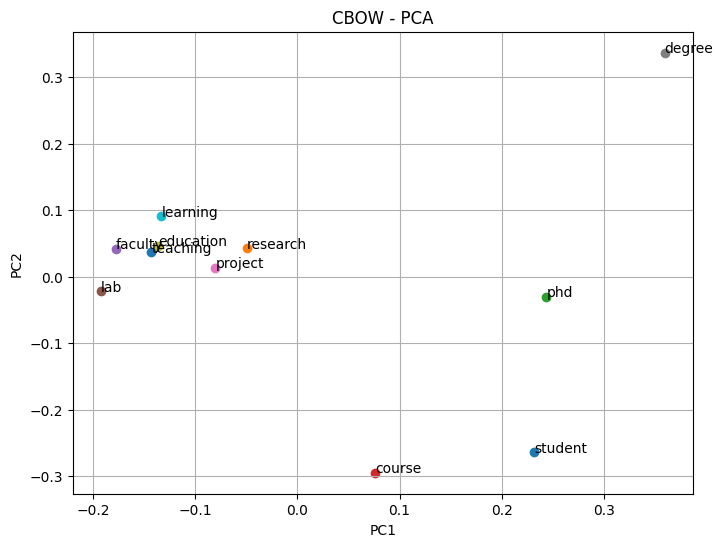

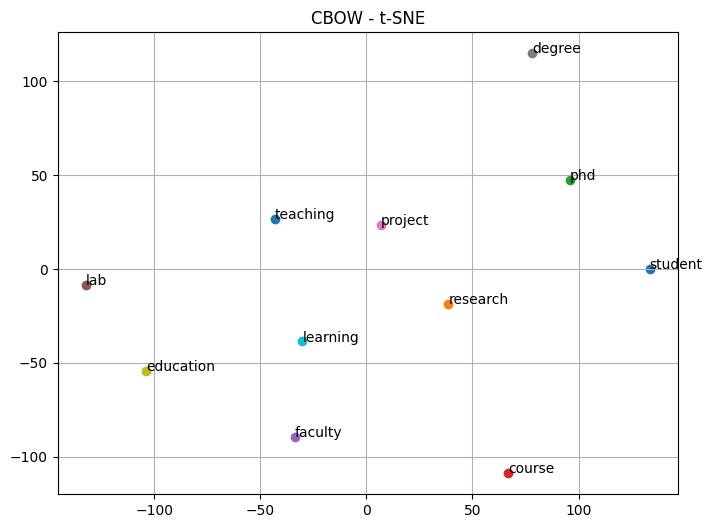

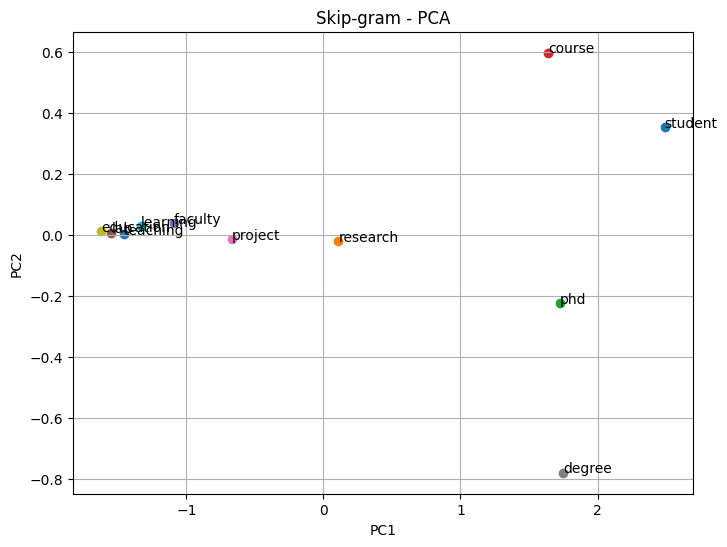

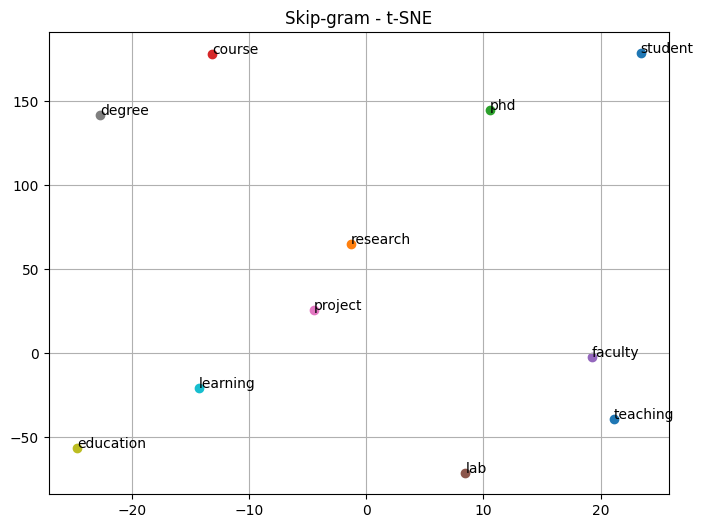

In [66]:
# CBOW visualization
plot_pca(selected_words, cbow_model, "CBOW - PCA")
plot_tsne(selected_words, cbow_model, "CBOW - t-SNE")

# Skip-gram visualization
plot_pca(selected_words, sg_model, "Skip-gram - PCA")
plot_tsne(selected_words, sg_model, "Skip-gram - t-SNE")